# Etapa 4 — Estratégia de corrida e ultrapassagens

In [1]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import sys
sys.path.append('../src')

from data_loader import processar_corrida, plotar_estrategia, plotar_degradacao, ultrapassagens_estrategia

## Exploração inicial — estratégia de pneus e degradação (Bahrain 2025)

Antes de generalizar em funções, a análise foi construída e validada numa corrida só (Bahrain), pra entender o comportamento dos dados.

In [37]:
bahrain = processar_corrida(2025, 'Bahrain')
voltas_piloto = bahrain[bahrain['Driver'] == 'HAM']
stint1 = voltas_piloto[voltas_piloto['Stint'] == 1]

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5', '55', '27']


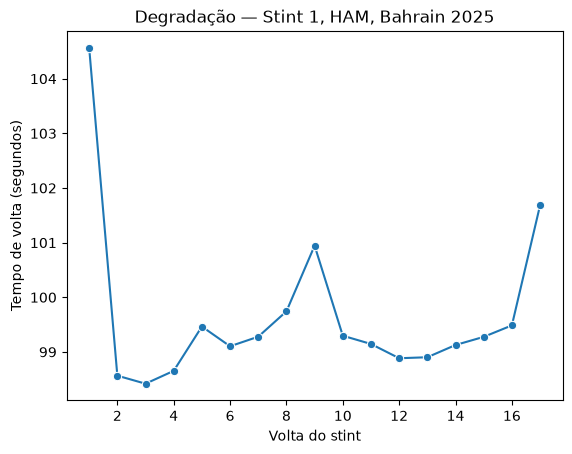

In [3]:
sns.lineplot(data=stint1, x='VoltaNoStint', y='LapTimeSeconds', marker='o')
plt.xlabel('Volta do stint')
plt.ylabel('Tempo de volta (segundos)')
plt.title('Degradação — Stint 1, HAM, Bahrain 2025')
plt.show()

In [4]:
bahrain[bahrain['LapNumber'] == 9][['Driver', 'LapTimeSeconds', 'TrackStatus']]

,Driver,LapTimeSeconds,TrackStatus
8,PIA,98.800,1
65,RUS,98.900,1
122,NOR,99.104,1
179,LEC,99.164,1
236,HAM,100.945,1
293,VER,99.670,1
350,GAS,100.096,1
407,OCO,117.716,1
464,TSU,100.727,1
521,BEA,100.284,1


A volta 9 do Stint 1 aparece como outlier no gráfico de degradação, mas não foi por causa do pneu — checando o TrackStatus (pista livre) e cruzando com notícias da corrida, foi uma disputa de posição entre pilotos naquela volta. Por isso, outliers no gráfico de degradação precisam ser investigados antes de virar conclusão — nem todo pico é o pneu "acabando".

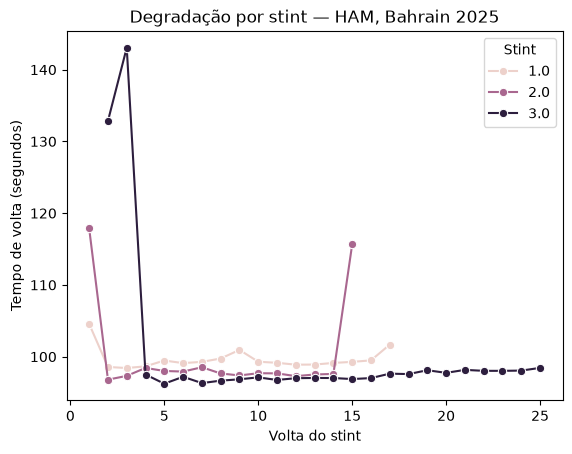

In [5]:
sns.lineplot(data=voltas_piloto, x='VoltaNoStint', y='LapTimeSeconds', hue='Stint', marker='o')
plt.xlabel('Volta do stint')
plt.ylabel('Tempo de volta (segundos)')
plt.title('Degradação por stint — HAM, Bahrain 2025')
plt.show()

O tempo de volta bruto fica mais estável do que o esperado ao longo do stint, mesmo com o pneu degradando — provável efeito do combustível: o carro fica mais leve ao longo da corrida (menos combustível = mais rápido), o que compensa parte da perda de performance do pneu. Análise futura poderia isolar o efeito puro do pneu corrigindo pelo combustível ("fuel-corrected lap time").

Testando por composto (`hue='Compound'`) em vez de por stint, o `sns.lineplot` sozinho mistura stints diferentes que usam o mesmo composto (ex: dois stints de MEDIUM viram uma única linha média, com uma faixa de confiança — escondendo a diferença real entre eles). Corrigido com `units='Stint', estimator=None`, forçando uma linha por stint sem agregar:

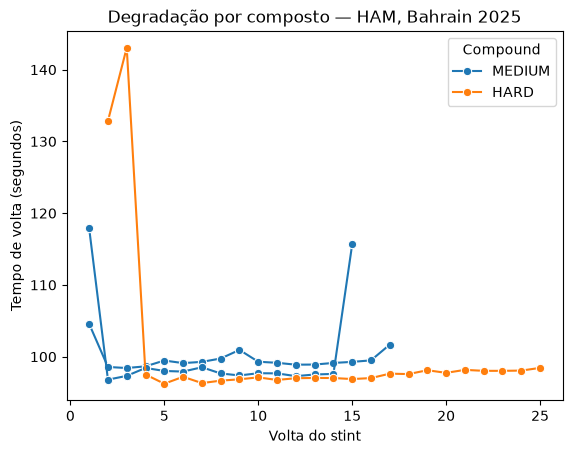

In [6]:
sns.lineplot(data=voltas_piloto, x='VoltaNoStint', y='LapTimeSeconds', hue='Compound', units='Stint', estimator=None, marker='o')
plt.xlabel('Volta do stint')
plt.ylabel('Tempo de volta (segundos)')
plt.title('Degradação por composto — HAM, Bahrain 2025')
plt.savefig('../reports/figures/degradacao_composto.png')
plt.show()

In [7]:
voltas_piloto.groupby('Stint')['LapTimeSeconds'].median()

Stint
1.0    99.276
2.0    97.674
3.0    97.356
Name: LapTimeSeconds, dtype: float64

A mediana do tempo de volta cai a cada stint (99.28s → 97.67s → 97.36s), seguindo a ordem cronológica da corrida — reforça o efeito de combustível (carro mais leve com o passar da corrida) como um fator forte no tempo de volta bruto, possivelmente mais forte que o composto de pneu nesse exemplo.

## Estratégia de pneus (Gantt) e generalização em funções

As duas análises acima (Gantt e degradação) foram generalizadas em funções reutilizáveis (`plotar_estrategia`, `plotar_degradacao`, ambas em `src/data_loader.py`), junto com `processar_corrida(ano, gp)` pra carregar qualquer corrida da temporada.

In [8]:
calendario = fastf1.get_event_schedule(2025)
corridas = calendario[calendario['RoundNumber'] > 0]

In [38]:
tabelas = []
falhas = []

for rodada in corridas['RoundNumber']:
    try:
         tabela = processar_corrida(2025, rodada)
         tabelas.append(tabela)
    except Exception as e:
        print(f"Falha na rodada {rodada}: {e}")
        falhas.append(rodada)

len(tabelas), falhas

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INF

(24, [])

In [10]:
corridas_2025 = pd.concat(tabelas, ignore_index=True)
corridas_2025.shape

(26689, 35)

In [11]:
corridas_2025.to_csv('../data/processed/corridas_2025.csv', index=False)

### Validando as funções generalizadas

Testadas numa corrida diferente da que foi usada pra construir (Bahrain → Australian GP), confirmando que funcionam pra qualquer corrida da temporada:

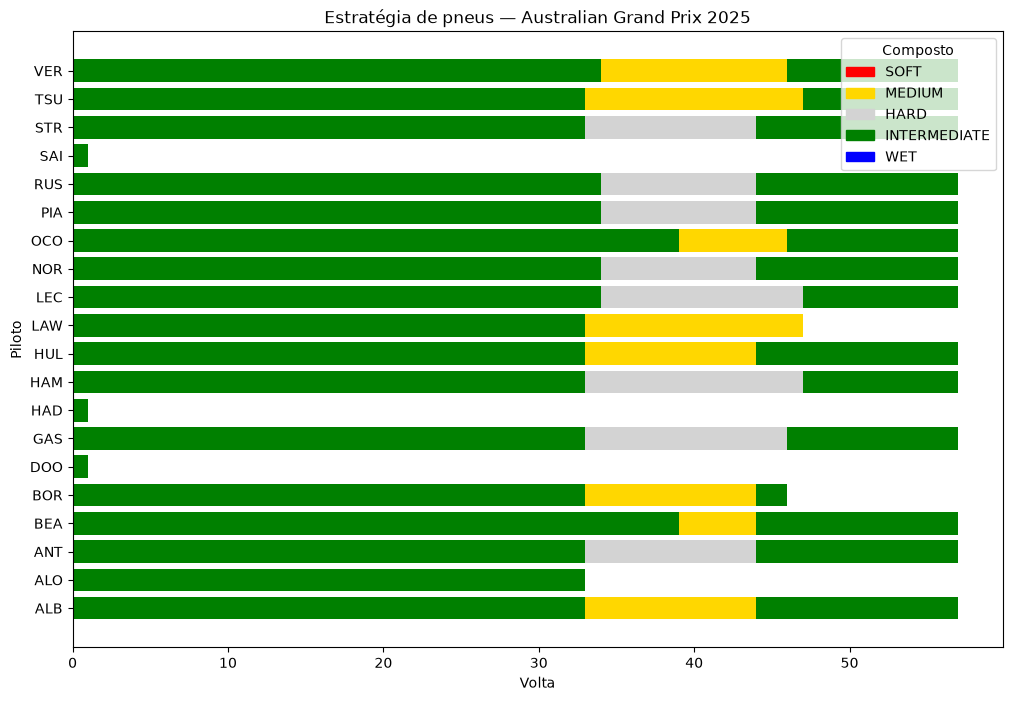

In [12]:
teste2 = corridas_2025[corridas_2025['GP'] == 'Australian Grand Prix']
plotar_estrategia(teste2)

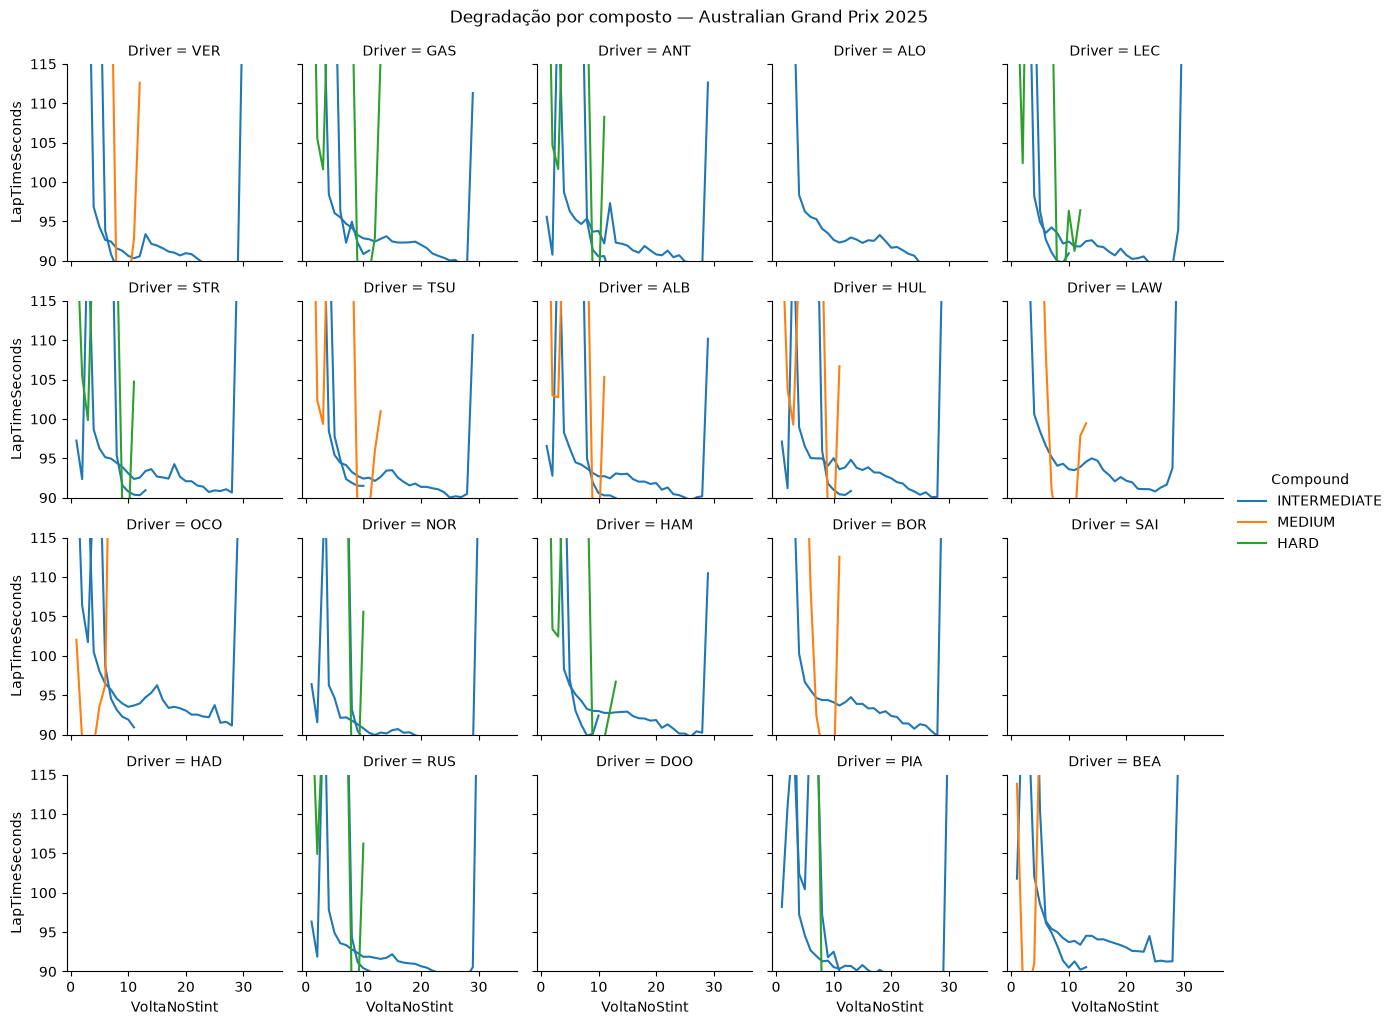

In [13]:
plotar_degradacao(teste2)

## Ultrapassagens

Variação de `Position` volta a volta, separando ultrapassagens reais (na pista) de mudanças causadas por pit stop.

`.diff()` -> negativo = ganhou posição (número caiu), positivo = perdeu posição (número subiu), zero = ficou igual.

In [14]:
laps_bahrain_completo = processar_corrida(2025, 'Bahrain')
laps_bahrain_completo = laps_bahrain_completo.sort_values(['Driver', 'LapNumber'])
laps_bahrain_completo['MudancaPosicao'] = laps_bahrain_completo.groupby('Driver')['Position'].diff()
laps_bahrain_completo['VoltaDePit'] = laps_bahrain_completo['PitInTime'].notna() | laps_bahrain_completo['PitOutTime'].notna()

ver_total = laps_bahrain_completo[laps_bahrain_completo['Driver'] == 'VER']
ver_total['MudancaPosicao'].sum()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5', '55', '27']


np.float64(-2.0)

In [15]:
ver_total[ver_total['VoltaDePit']][['LapNumber', 'Position', 'MudancaPosicao']]

,LapNumber,Position,MudancaPosicao
294,10.0,7.0,0.0
295,11.0,17.0,10.0
310,26.0,11.0,2.0
311,27.0,19.0,8.0


VER terminou Bahrain com saldo total de apenas -2 (ganhou 2 posições na corrida toda) — mas separando os componentes, ele teve +22 de ultrapassagens reais na pista (excluindo voltas de pit), e perdeu 20 posições só nas voltas de pit (dois pit stops caros, voltas 11 e 27). O número final (líquido) esconde uma corrida muito mais dramática por dentro — daí a necessidade de separar "ultrapassagem real" de "perda em pit stop" na função abaixo, em vez de olhar só o resultado final.

### Função `ultrapassagens_estrategia(laps)`

Generaliza a lógica acima (diferença de posição, filtro de pit stop) pra qualquer corrida ou pra temporada inteira, devolvendo ultrapassagens reais, mudança nos pits e o resultado líquido por piloto:

In [16]:
teste2 = corridas_2025[corridas_2025['GP'] == 'Australian Grand Prix']
ultrapassagens_estrategia(teste2)

Ultrapassagens reais  \
GP                    Driver                         
Australian Grand Prix ALB                     -4.0   
                      ALO                      0.0   
                      ANT                     -9.0   
                      BEA                     -4.0   
                      BOR                      0.0   
                      DOO                      0.0   
                      GAS                     -2.0   
                      HAD                      0.0   
                      HAM                     -6.0   
                      HUL                     -4.0   
                      LAW                     -8.0   
                      LEC                     -5.0   
                      NOR                     -5.0   
                      OCO                     -1.0   
                      PIA                     -7.0   
                      RUS                     -5.0   
                      SAI                      0.0   
                      STR                     -3.0   
                      TSU                     -1.0   
                      VER                     -1.0   

                              Mudancas de posicao (pitstop)  \
GP                    Driver                                  
Australian Grand Prix ALB                               2.0   
                      ALO                               0.0   
                      ANT                               0.0   
                      BEA                               1.0   
                      BOR                              -1.0   
                      DOO                               NaN   
                      GAS                               4.0   
                      HAD                               NaN   
                      HAM                               8.0   
                      HUL                              -1.0   
                      LAW                               1.0   
                      LEC                               8.0   
                      NOR                               5.0   
                      OCO                              -1.0   
                      PIA                              13.0   
                      RUS                               4.0   
                      SAI                               NaN   
                      STR                              -2.0   
                      TSU                               7.0   
                      VER                               1.0   

                              Ultrapassagens liquidas  
GP                    Driver                           
Australian Grand Prix ALB                        -2.0  
                      ALO                         0.0  
                      ANT                        -9.0  
                      BEA                        -3.0  
                      BOR                        -1.0  
                      DOO                         0.0  
                      GAS                         2.0  
                      HAD                         0.0  
                      HAM                         2.0  
                      HUL                        -5.0  
                      LAW                        -7.0  
                      LEC                         3.0  
                      NOR                         0.0  
                      OCO                        -2.0  
                      PIA                         6.0  
                      RUS                        -1.0  
                      SAI                         0.0  
                      STR                        -5.0  
                      TSU                         6.0  
                      VER                         0.0

In [17]:
stints_por_piloto = corridas_2025.groupby(['GP', 'Driver'])['Stint'].max()

In [18]:
paradas_por_piloto = stints_por_piloto - 1

In [19]:
resultado_ultrapassagens = ultrapassagens_estrategia(corridas_2025)

In [20]:
resultado_ultrapassagens['Paradas'] = paradas_por_piloto

In [21]:
resultado_ultrapassagens.groupby('Paradas')['Ultrapassagens liquidas'].median()

Paradas
0.0    0.0
1.0    0.0
2.0    0.0
3.0    0.0
4.0   -3.5
5.0    0.0
6.0    1.0
Name: Ultrapassagens liquidas, dtype: float64

In [22]:
resultado_ultrapassagens.groupby('Paradas')['Ultrapassagens liquidas'].count()

Paradas
0.0     20
1.0    222
2.0    166
3.0     32
4.0     12
5.0     23
6.0      1
Name: Ultrapassagens liquidas, dtype: int64

## 1 parada vs. 2 paradas — qual rendeu mais posições?

Comparando a mediana de Ultrapassagens liquidas por número de paradas na temporada 2025:

| Paradas | Amostra | Mediana |
|---------|---------|---------|
| 1 | 222 | 0.0 |
| 2 | 166 | 0.0 |
| 4 | 12 | -3.5 |

Com amostras grandes (222 e 166 casos), 1 e 2 paradas tiveram exatamente a mesma mediana — nenhuma das duas estratégias mostrou vantagem sistemática sobre a outra na temporada. Faz sentido: as equipes escolhem a estratégia mais adequada pra cada pista/corrida, então no agregado elas se equilibram.

Já os casos de 4 paradas (amostra pequena, 12 casos) mostraram mediana negativa — mais paradas do que o padrão normalmente indica que algo deu errado na corrida (dano, safety car mal aproveitado, mudança de clima), não uma escolha estratégica deliberada. Cada parada custa cerca de 20s fixos, então paradas extras tendem a custar caro em posições.

## Undercut funcionou?

Tentativa original: comparar pilotos que pitaram perto um do outro, verificando se quem parou primeiro ganhou do rival. Olhando as voltas de pit do Bahrain:

In [23]:
laps_bahrain = processar_corrida(2025, 'Bahrain')

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5', '55', '27']


In [24]:
pit_bahrain = laps_bahrain['PitInTime'].notna() | laps_bahrain['PitOutTime'].notna()

In [25]:
laps_bahrain[pit_bahrain][['Driver', 'LapNumber', 'Position']].sort_values('LapNumber')

,Driver,LapNumber,Position
1075,HUL,5.0,20.0
1076,HUL,6.0,20.0
689,HAD,6.0,18.0
690,HAD,7.0,20.0
406,OCO,8.0,13.0
...,...,...,...
887,LAW,33.0,18.0
146,NOR,33.0,4.0
659,ALB,33.0,13.0
1069,SAI,44.0,20.0


Essa tabela revela dois problemas: muitas paradas caem exatamente na mesma volta (não dá pra saber quem pitou primeiro), e há um aglomerado de ~14 pilotos parando juntos nas voltas 32-33 — bate com o Safety Car da corrida, onde o prejuízo de parar é bem menor (não é um bom lugar pra procurar undercut). Por isso, simplificamos a pergunta usando o pneu novo como proxy de vantagem:

In [26]:
corridas_2025['MudancaPosicao'] = corridas_2025.groupby(['GP', 'Driver'])['Position'].diff()
corridas_2025['VoltaDePit'] = corridas_2025['PitInTime'].notna() | corridas_2025['PitOutTime'].notna()

In [27]:
voltas_recentes_pit = corridas_2025[(corridas_2025['VoltaNoStint'] >= 2) & (corridas_2025['VoltaNoStint'] <= 4) & (~corridas_2025['VoltaDePit'])]

In [28]:
voltas_recentes_pit['MudancaPosicao'].mean()

np.float64(-0.20129107981220656)

In [29]:
corridas_2025[~corridas_2025['VoltaDePit']]['MudancaPosicao'].mean()

np.float64(-0.11943147208121828)

### Undercut funcionou?

Tentamos isolar duelos específicos entre pilotos (quem pitou primeiro ganhou do rival?), mas a granularidade de volta (números inteiros) não permite isso com confiança — muitas paradas aparecem na mesma volta exata, e não dá pra saber quem exatamente estava correndo contra quem.

Simplificamos a pergunta usando a vantagem de pneu novo como proxy: comparamos `MudancaPosicao` nas primeiras voltas de um stint novo (`VoltaNoStint` 2 a 4, já fora da própria volta de pit) contra a média geral de todas as voltas fora de pit da temporada.

| Período | Média de MudancaPosicao |
|---------|--------------------------|
| Logo após o pit (VoltaNoStint 2-4) | -0.20 |
| Resto da corrida (todas as voltas fora de pit) | -0.12 |

Pilotos ganham posição (negativo = subiu) nas voltas logo depois de trocar pneu, bem mais do que a média do resto da corrida (~0.08 posições/volta de diferença). Isso confirma que a vantagem de pneu novo se traduz em ganho real de posição acima da média — o mecanismo por trás do undercut existe nos dados, mesmo sem conseguir provar casos específicos de "piloto A undercutou o piloto B".

In [30]:
corridas_2025['MovimentacaoAbsoluta'] = corridas_2025['MudancaPosicao'].abs()

In [31]:
ultrapassagens_por_pista = corridas_2025[~corridas_2025['VoltaDePit']].groupby('GP')['MovimentacaoAbsoluta'].sum().sort_values(ascending=False)

In [32]:
ultrapassagens_por_pista

GP
São Paulo Grand Prix         355.0
Bahrain Grand Prix           333.0
Abu Dhabi Grand Prix         274.0
Emilia Romagna Grand Prix    244.0
Spanish Grand Prix           242.0
Canadian Grand Prix          231.0
Mexico City Grand Prix       212.0
Hungarian Grand Prix         209.0
Chinese Grand Prix           197.0
Austrian Grand Prix          194.0
British Grand Prix           190.0
Dutch Grand Prix             185.0
Singapore Grand Prix         181.0
United States Grand Prix     173.0
Italian Grand Prix           167.0
Saudi Arabian Grand Prix     136.0
Japanese Grand Prix          134.0
Azerbaijan Grand Prix        128.0
Belgian Grand Prix           126.0
Las Vegas Grand Prix         124.0
Qatar Grand Prix             107.0
Miami Grand Prix             105.0
Australian Grand Prix        103.0
Monaco Grand Prix             97.0
Name: MovimentacaoAbsoluta, dtype: float64

In [33]:
voltas_por_pista = corridas_2025.groupby('GP')['LapNumber'].max()

In [34]:
ultrapassagens_normalizada = (ultrapassagens_por_pista / voltas_por_pista).sort_values(ascending=False)

In [35]:
ultrapassagens_normalizada

GP
Bahrain Grand Prix           5.842105
São Paulo Grand Prix         5.000000
Abu Dhabi Grand Prix         4.724138
Emilia Romagna Grand Prix    3.873016
Spanish Grand Prix           3.666667
British Grand Prix           3.653846
Chinese Grand Prix           3.517857
Canadian Grand Prix          3.300000
Italian Grand Prix           3.150943
United States Grand Prix     3.089286
Mexico City Grand Prix       2.985915
Hungarian Grand Prix         2.985714
Singapore Grand Prix         2.919355
Belgian Grand Prix           2.863636
Austrian Grand Prix          2.771429
Saudi Arabian Grand Prix     2.720000
Dutch Grand Prix             2.569444
Japanese Grand Prix          2.528302
Azerbaijan Grand Prix        2.509804
Las Vegas Grand Prix         2.480000
Qatar Grand Prix             1.877193
Miami Grand Prix             1.842105
Australian Grand Prix        1.807018
Monaco Grand Prix            1.243590
dtype: float64

### Em quais pistas se ultrapassa mais?

Medimos "ultrapassagem" como a soma do valor absoluto (`.abs()`) de `MudancaPosicao` fora das voltas de pit, por pista — usamos valor absoluto porque a soma direta sempre cancela pra ~0 (ganhos e perdas de posição se equilibram numa mesma volta).

Normalizamos pelo número de voltas de cada corrida, já que corridas têm distâncias diferentes:

| Pista | Movimentação/volta |
|-------|---------------------|
| Bahrain | 5.84 |
| São Paulo | 5.00 |
| Abu Dhabi | 4.72 |
| ... | ... |
| Monaco | 1.24 |

Monaco fica em último tanto no total bruto quanto normalizado — confirma o que é conhecido no automobilismo: é a pista mais difícil de ultrapassar do calendário (circuito de rua estreito). Bahrain e São Paulo lideram, consistente com corridas historicamente disputadas nessas pistas.

## Conclusão da Etapa 4

Estratégia de pneus, degradação por composto e ultrapassagens (com as 3 perguntas do roadmap) — todas as funções generalizadas e movidas para `src/data_loader.py` (Etapa 5).